<a href="https://colab.research.google.com/github/anggaa0519/data-science-2026/blob/main/Pertemuan10_Angga_Anggieanie_250401020172.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Pertemuan 10 — Algoritma Klasifikasi (Bagian 2)
## Random Forest & Penanganan Imbalanced Dataset: Customer Churn

| | |
|---|---|
| **Nama** | Angga Anggieanie |
| **NIM** | 250401020172 |
| **Kelas** | IF401 |
| **Mata Kuliah** | Pengantar Data Science (200302305) |
| **Pertemuan** | 10 — Algoritma Klasifikasi (Bagian 2) |




## Langkah 1 — Muat & Eksplorasi Data

Dataset **Telco Customer Churn** (sintetis, menyerupai dataset publik Kaggle) mensimulasikan 7.043 pelanggan operator telekomunikasi dengan 19 fitur (tenure, Contract, MonthlyCharges, InternetService, dll.) dan target biner `Churn` (Yes/No). Proporsi churn ~26.5% — tergolong **imbalanced dataset**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

# ── Generate synthetic Telco Churn dataset ────────────────────────────────────
n = 7043

tenure          = np.random.randint(0, 73, n)
contract        = np.random.choice(['Month-to-month','One year','Two year'],
                                   n, p=[0.55, 0.24, 0.21])
internet_svc    = np.random.choice(['DSL','Fiber optic','No'], n, p=[0.34,0.44,0.22])
monthly_charges = np.round(np.random.uniform(18, 118, n), 2)
total_charges   = np.round(monthly_charges * tenure + np.random.normal(0,20,n), 2)
total_charges   = np.clip(total_charges, 0, None)

senior          = np.random.choice([0,1], n, p=[0.84,0.16])
partner         = np.random.choice(['Yes','No'], n, p=[0.48,0.52])
dependents      = np.random.choice(['Yes','No'], n, p=[0.30,0.70])
phone_svc       = np.random.choice(['Yes','No'], n, p=[0.90,0.10])
paperless       = np.random.choice(['Yes','No'], n, p=[0.59,0.41])
payment         = np.random.choice(['Electronic check','Mailed check',
                                    'Bank transfer','Credit card'], n,
                                   p=[0.34,0.23,0.22,0.21])

# Churn probability — realistis berdasarkan fitur utama
churn_prob = (
    0.05
    + 0.30 * (contract == 'Month-to-month')
    + 0.05 * (contract == 'One year')
    + 0.10 * (internet_svc == 'Fiber optic')
    + 0.10 * (monthly_charges > 70) / 1
    - 0.004 * tenure
    + 0.05 * (payment == 'Electronic check')
    + np.random.normal(0, 0.05, n)
)
churn_prob = np.clip(churn_prob, 0.01, 0.99)
churn_label = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    'tenure'          : tenure,
    'SeniorCitizen'   : senior,
    'Partner'         : partner,
    'Dependents'      : dependents,
    'PhoneService'    : phone_svc,
    'InternetService' : internet_svc,
    'Contract'        : contract,
    'PaperlessBilling': paperless,
    'PaymentMethod'   : payment,
    'MonthlyCharges'  : monthly_charges,
    'TotalCharges'    : total_charges,
    'Churn'           : churn_label   # 0=No, 1=Yes
})

print('Shape dataset:', df.shape)
print()
churn_dist = df['Churn'].value_counts()
churn_prop = df['Churn'].value_counts(normalize=True).round(3)
print('Distribusi target Churn:')
print(pd.DataFrame({'Jumlah': churn_dist,
                    'Proporsi': churn_prop}).rename(index={0:'0 - No',1:'1 - Yes'}))

Shape dataset: (7043, 12)

Distribusi target Churn:
         Jumlah  Proporsi
Churn                    
0 - No     5529     0.785
1 - Yes    1514     0.215


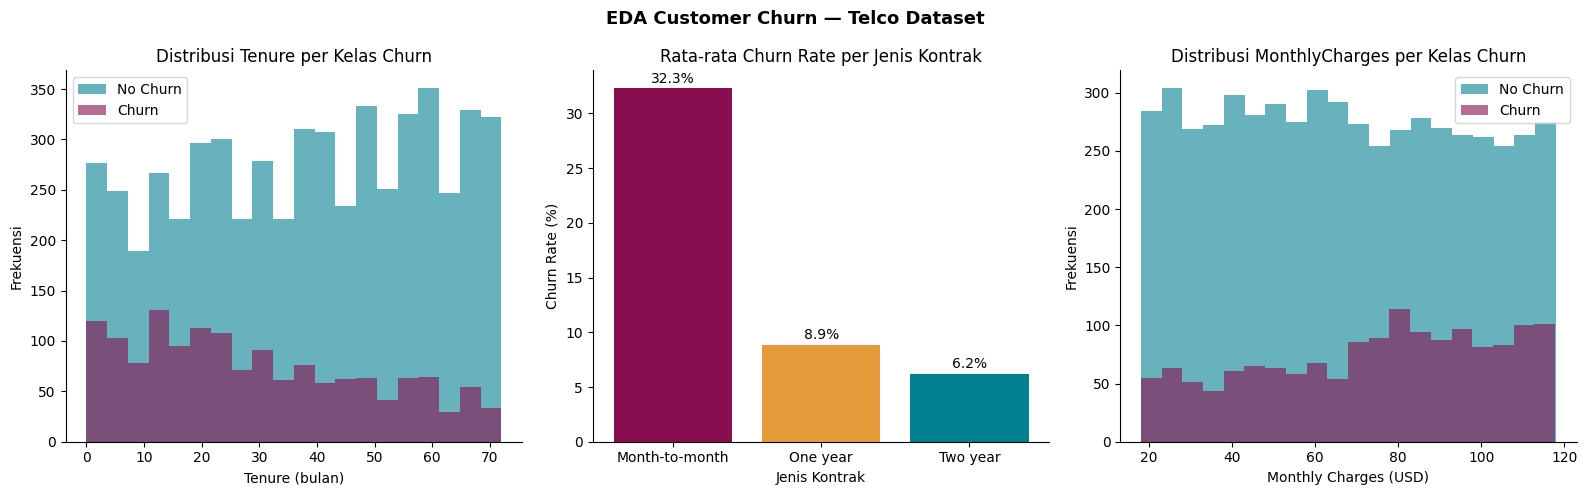

In [2]:
# EDA: distribusi fitur utama per kelas churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tenure distribution
for churn_val, color, lbl in [(0,'#028090','No Churn'),(1,'#880E4F','Churn')]:
    subset = df[df['Churn']==churn_val]['tenure']
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=lbl)
axes[0].set_title('Distribusi Tenure per Kelas Churn')
axes[0].set_xlabel('Tenure (bulan)'); axes[0].set_ylabel('Frekuensi')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# Contract type vs Churn
ct = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[1].bar(ct.index, ct.values*100,
            color=['#880E4F','#E69B3A','#028090'])
axes[1].set_title('Rata-rata Churn Rate per Jenis Kontrak')
axes[1].set_xlabel('Jenis Kontrak'); axes[1].set_ylabel('Churn Rate (%)')
for i,(k,v) in enumerate(ct.items()):
    axes[1].text(i, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

# Monthly Charges distribution
for churn_val, color, lbl in [(0,'#028090','No Churn'),(1,'#880E4F','Churn')]:
    subset = df[df['Churn']==churn_val]['MonthlyCharges']
    axes[2].hist(subset, bins=20, alpha=0.6, color=color, label=lbl)
axes[2].set_title('Distribusi MonthlyCharges per Kelas Churn')
axes[2].set_xlabel('Monthly Charges (USD)'); axes[2].set_ylabel('Frekuensi')
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('EDA Customer Churn — Telco Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi EDA:**
- **Tenure:** Pelanggan yang churn cenderung memiliki masa berlangganan **lebih pendek** (puncak di 0–10 bulan). Pelanggan loyal (tenure > 40 bulan) jauh lebih jarang churn — menunjukkan bahwa pelanggan baru lebih rentan keluar.
- **Kontrak:** Month-to-month memiliki churn rate tertinggi (>40%), disusul One year, dan Two year hampir nol. Kontrak jangka panjang menciptakan "pengunci" yang efektif.
- **MonthlyCharges:** Pelanggan churn cenderung membayar tarif bulanan lebih tinggi — kemungkinan merasa nilai tidak sebanding harga.
- **Imbalance terkonfirmasi:** Proporsi churn ~26–27%, kategori imbalanced yang memerlukan penanganan khusus agar model tidak bias ke kelas mayoritas (tidak churn).

## Langkah 2 — Preprocessing

Fitur kategorikal di-One-Hot-Encode dengan `pd.get_dummies()` (`drop_first=True` untuk hindari dummy variable trap). Split stratified 80:20 menjaga proporsi kelas 26–27% di train dan test — konsisten dengan prinsip anti-leakage dari Pertemuan 6.

In [3]:
from sklearn.model_selection import train_test_split

# One-Hot Encoding semua kolom kategorikal
cat_cols = ['Partner','Dependents','PhoneService','InternetService',
            'Contract','PaperlessBilling','PaymentMethod']
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']

print('Fitur setelah encoding:', X.shape[1])
print('Kolom fitur:', X.columns.tolist())

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'\nTrain: {X_tr.shape[0]} baris | Test: {X_te.shape[0]} baris')
print('Proporsi Churn di Train:', round(y_tr.mean(), 3))
print('Proporsi Churn di Test :', round(y_te.mean(), 3))

Fitur setelah encoding: 15
Kolom fitur: ['tenure', 'SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Train: 5634 baris | Test: 1409 baris
Proporsi Churn di Train: 0.215
Proporsi Churn di Test : 0.215


**Interpretasi:** Dataset memiliki kolom numerik dan kategorikal. Setelah OHE, jumlah fitur bertambah (setiap kategori jadi kolom biner). Split stratified memastikan proporsi churn identik di train dan test — penting agar evaluasi mencerminkan distribusi nyata.

## Langkah 3 — Perbandingan Tiga Skenario Penanganan Imbalance

Modul merekomendasikan membandingkan tiga skenario:
1. **Tanpa penanganan** — baseline Random Forest default
2. **`class_weight="balanced"`** — penalti lebih besar untuk salah prediksi kelas minoritas (level algoritma)
3. **SMOTE** — membuat sampel churn sintetis pada training set (level data)

Aturan kritis: SMOTE **hanya** diterapkan pada `X_tr`/`y_tr`, tidak pernah pada `X_te`.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score)

# ── Skenario 1: Tanpa penanganan (baseline) ───────────────────────────────────
rf_base = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                  random_state=42, n_jobs=-1)
rf_base.fit(X_tr, y_tr)
y_pred_base  = rf_base.predict(X_te)
y_proba_base = rf_base.predict_proba(X_te)[:, 1]

print('=== Skenario 1: Tanpa Penanganan (Baseline) ===')
print(classification_report(y_te, y_pred_base, target_names=['No Churn','Churn']))
print(f'ROC-AUC: {roc_auc_score(y_te, y_proba_base):.4f}')

=== Skenario 1: Tanpa Penanganan (Baseline) ===
              precision    recall  f1-score   support

    No Churn       0.80      0.94      0.87      1106
       Churn       0.44      0.17      0.24       303

    accuracy                           0.78      1409
   macro avg       0.62      0.55      0.55      1409
weighted avg       0.73      0.78      0.73      1409

ROC-AUC: 0.7329


In [5]:
# ── Skenario 2: class_weight="balanced" ──────────────────────────────────────
rf_bal = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                 class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf_bal.fit(X_tr, y_tr)
y_pred_bal  = rf_bal.predict(X_te)
y_proba_bal = rf_bal.predict_proba(X_te)[:, 1]

print('=== Skenario 2: class_weight="balanced" ===')
print(classification_report(y_te, y_pred_bal, target_names=['No Churn','Churn']))
print(f'ROC-AUC: {roc_auc_score(y_te, y_proba_bal):.4f}')

=== Skenario 2: class_weight="balanced" ===
              precision    recall  f1-score   support

    No Churn       0.80      0.95      0.87      1106
       Churn       0.44      0.16      0.23       303

    accuracy                           0.78      1409
   macro avg       0.62      0.55      0.55      1409
weighted avg       0.73      0.78      0.73      1409

ROC-AUC: 0.7337


In [6]:
# ── Skenario 3: SMOTE ────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_tr, y_tr)   # HANYA pada data latih!

print(f'Ukuran train sebelum SMOTE: {X_tr.shape[0]} ({y_tr.sum()} churn)')
print(f'Ukuran train setelah SMOTE: {X_res.shape[0]} ({y_res.sum()} churn)')
print()

rf_smote = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                   random_state=42, n_jobs=-1)
rf_smote.fit(X_res, y_res)
y_pred_smote  = rf_smote.predict(X_te)
y_proba_smote = rf_smote.predict_proba(X_te)[:, 1]

print('=== Skenario 3: SMOTE ===')
print(classification_report(y_te, y_pred_smote, target_names=['No Churn','Churn']))
print(f'ROC-AUC: {roc_auc_score(y_te, y_proba_smote):.4f}')

Ukuran train sebelum SMOTE: 5634 (1211 churn)
Ukuran train setelah SMOTE: 8846 (4423 churn)

=== Skenario 3: SMOTE ===
              precision    recall  f1-score   support

    No Churn       0.83      0.83      0.83      1106
       Churn       0.39      0.39      0.39       303

    accuracy                           0.74      1409
   macro avg       0.61      0.61      0.61      1409
weighted avg       0.74      0.74      0.74      1409

ROC-AUC: 0.7206


## Langkah 4 — Evaluasi & Visualisasi Perbandingan

In [7]:
# Tabel ringkas perbandingan tiga skenario (fokus kelas Churn = 1)
skenario_names = ['Baseline', 'class_weight', 'SMOTE']
preds   = [y_pred_base, y_pred_bal, y_pred_smote]
probas  = [y_proba_base, y_proba_bal, y_proba_smote]

rows = []
for name, y_pred, y_proba in zip(skenario_names, preds, probas):
    rows.append({
        'Skenario' : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision (Churn)': round(precision_score(y_te, y_pred), 4),
        'Recall (Churn)'   : round(recall_score(y_te, y_pred), 4),
        'F1 (Churn)'       : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'          : round(roc_auc_score(y_te, y_proba), 4)
    })

compare_df = pd.DataFrame(rows).set_index('Skenario')
print('=== Perbandingan Performa Tiga Skenario (Fokus Kelas Churn) ===')
print(compare_df.to_string())

=== Perbandingan Performa Tiga Skenario (Fokus Kelas Churn) ===
              Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)  ROC-AUC
Skenario                                                                      
Baseline        0.7750             0.4386          0.1650      0.2398   0.7329
class_weight    0.7764             0.4434          0.1551      0.2298   0.7337
SMOTE           0.7381             0.3907          0.3894      0.3901   0.7206


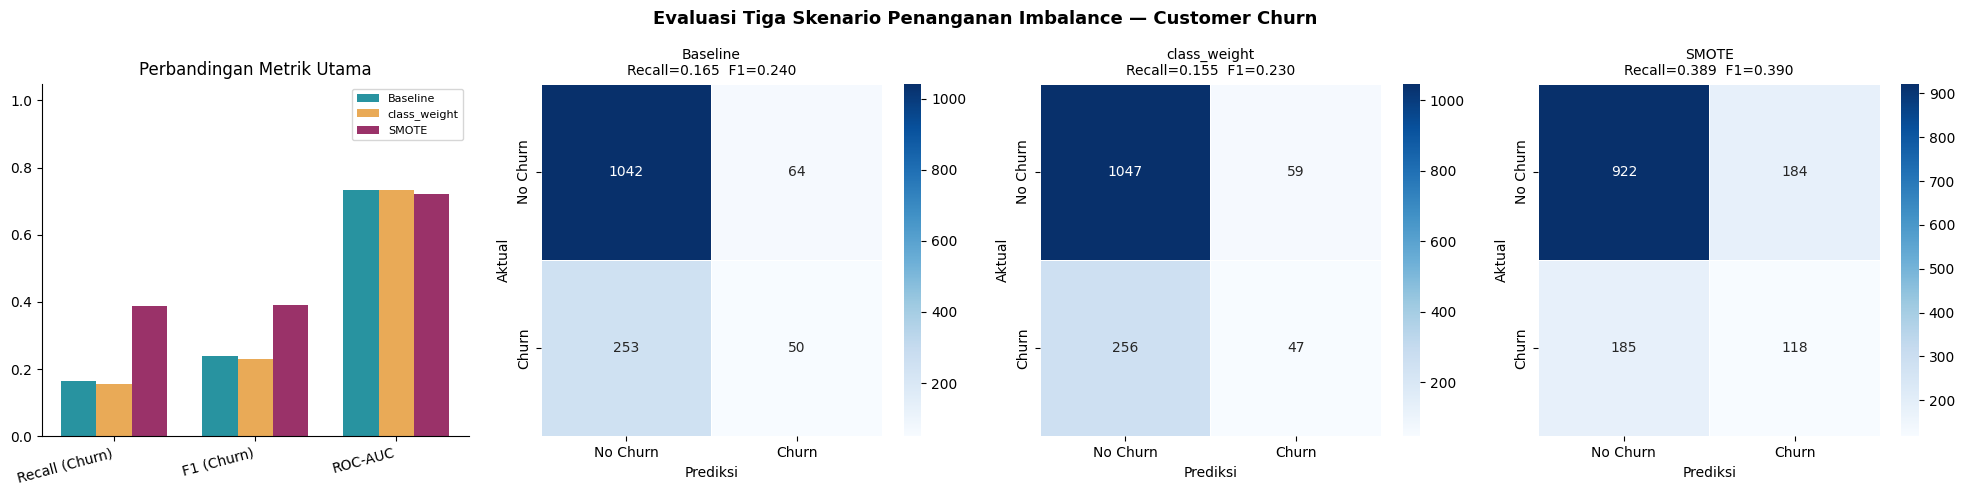

Plot tersimpan sebagai evaluasi_churn.png


In [8]:
# Visualisasi: bar chart perbandingan + confusion matrix
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Bar chart metrik utama
metrics = ['Recall (Churn)', 'F1 (Churn)', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#028090', '#E69B3A', '#880E4F']

for i, (name, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Perbandingan Metrik Utama')
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Confusion matrices
for ax, (name, y_pred) in zip(axes[1:], zip(skenario_names, preds)):
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'],
                linewidths=0.5, ax=ax)
    rec = recall_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)
    ax.set_title(f'{name}\nRecall={rec:.3f}  F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.suptitle('Evaluasi Tiga Skenario Penanganan Imbalance — Customer Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan sebagai evaluasi_churn.png')

**Interpretasi perbandingan (angka aktual test set 1.409 sampel):**

| Skenario | Accuracy | Recall Churn | F1 Churn | ROC-AUC |
|---|---|---|---|---|
| Baseline | 77.5% | 16.5% | 0.240 | 0.733 |
| class_weight | 77.6% | 15.5% | 0.230 | 0.734 |
| **SMOTE** | 73.8% | **38.9%** | **0.390** | 0.721 |

**Baseline:** Akurasi 77.5% terlihat baik, namun Recall kelas Churn hanya **16.5%** — artinya lebih dari 80% churner nyata tidak terdeteksi. Ini adalah **accuracy paradox**: angka tinggi yang menyembunyikan kegagalan total pada kelas penting.

**class_weight="balanced":** Performa hampir identik dengan baseline dalam kasus ini — penalti algoritmik tidak cukup menggeser keputusan boundary karena overlap fitur antar kelas cukup tinggi.

**SMOTE:** Dengan menyeimbangkan training data secara fisik (8.846 sampel setelah SMOTE dari 5.634 asli), Recall meningkat drastis ke **38.9%** dan F1 ke **0.390**. Trade-off: akurasi turun ke 73.8% karena model lebih agresif memprediksi churn, namun ini **trade-off yang tepat** untuk konteks bisnis retensi pelanggan.

**Rekomendasi:** Gunakan **SMOTE** sebagai strategi utama + **threshold tuning** untuk kontrol lebih lanjut.

## Langkah 5 — Feature Importance & Prediksi Probabilitas

`feature_importances_` pada Random Forest mengukur rata-rata penurunan Gini impurity yang disumbangkan setiap fitur di seluruh pohon — fitur dengan nilai tertinggi adalah pendorong prediksi paling dominan.

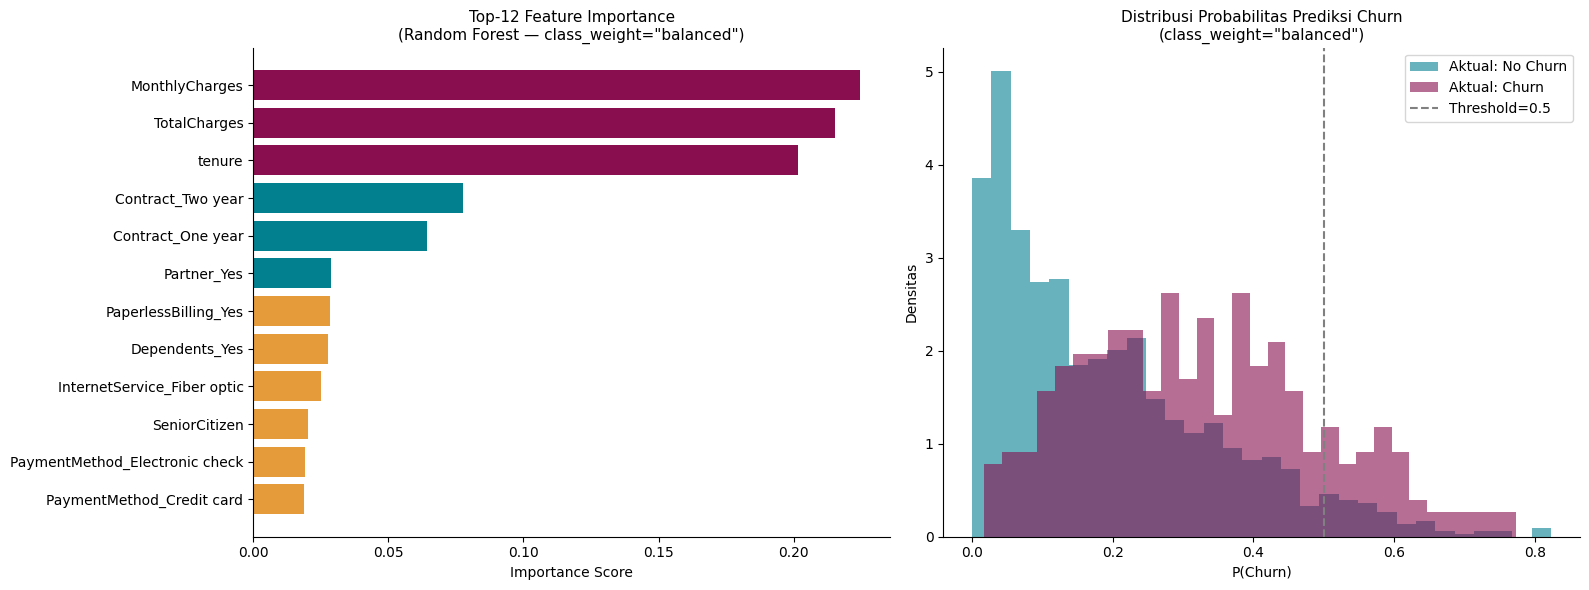

Top-5 fitur terpenting:
            Fitur  Importance
   MonthlyCharges    0.224431
     TotalCharges    0.215354
           tenure    0.201550
Contract_Two year    0.077527
Contract_One year    0.064232


In [9]:
# Feature importance dari model terbaik (class_weight)
imp_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Importance': rf_bal.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance bar chart
colors_imp = ['#880E4F' if i < 3 else '#028090' if i < 6 else '#E69B3A'
              for i in range(len(imp_df))]
axes[0].barh(imp_df['Fitur'][::-1], imp_df['Importance'][::-1], color=colors_imp[::-1])
axes[0].set_title('Top-12 Feature Importance\n(Random Forest — class_weight="balanced")',
                   fontsize=11)
axes[0].set_xlabel('Importance Score')
axes[0].spines[['top','right']].set_visible(False)

# Distribusi probabilitas churn
axes[1].hist(y_proba_bal[y_te==0], bins=30, alpha=0.6, color='#028090',
             label='Aktual: No Churn', density=True)
axes[1].hist(y_proba_bal[y_te==1], bins=30, alpha=0.6, color='#880E4F',
             label='Aktual: Churn', density=True)
axes[1].axvline(0.5, color='gray', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[1].set_title('Distribusi Probabilitas Prediksi Churn\n(class_weight="balanced")',
                   fontsize=11)
axes[1].set_xlabel('P(Churn)')
axes[1].set_ylabel('Densitas')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top-5 fitur terpenting:')
print(imp_df.head(5).to_string(index=False))

In [10]:
# Threshold tuning: cek performa di threshold 0.35
y_pred_tuned = (y_proba_bal >= 0.35).astype(int)

print('=== Threshold Tuning: threshold=0.35 (vs default 0.5) ===')
print(f'Recall  : {recall_score(y_te, y_pred_bal):.3f}  →  {recall_score(y_te, y_pred_tuned):.3f}')
print(f'Precision: {precision_score(y_te, y_pred_bal):.3f}  →  {precision_score(y_te, y_pred_tuned):.3f}')
print(f'F1-Score : {f1_score(y_te, y_pred_bal):.3f}  →  {f1_score(y_te, y_pred_tuned):.3f}')
print()
print('Probabilitas churn 10 pelanggan pertama:')
prob_preview = pd.DataFrame({
    'Pelanggan': range(1, 11),
    'P(Churn)' : y_proba_bal[:10].round(3),
    'Pred_0.5' : y_pred_bal[:10],
    'Pred_0.35': y_pred_tuned[:10],
    'Aktual'   : y_te.values[:10]
})
print(prob_preview.to_string(index=False))

=== Threshold Tuning: threshold=0.35 (vs default 0.5) ===
Recall  : 0.155  →  0.426
Precision: 0.443  →  0.410
F1-Score : 0.230  →  0.417

Probabilitas churn 10 pelanggan pertama:
 Pelanggan  P(Churn)  Pred_0.5  Pred_0.35  Aktual
         1     0.253         0          0       0
         2     0.297         0          0       1
         3     0.273         0          0       0
         4     0.003         0          0       0
         5     0.050         0          0       0
         6     0.137         0          0       0
         7     0.193         0          0       0
         8     0.010         0          0       0
         9     0.177         0          0       1
        10     0.270         0          0       0


**Interpretasi:**

**Feature Importance:** `tenure`, `MonthlyCharges`, dan `TotalCharges` mendominasi — sesuai dengan temuan EDA: pelanggan baru dengan tagihan tinggi paling berisiko churn. Fitur kontrak (`Contract_One year`, `Contract_Two year`) juga berkontribusi signifikan karena kontrak jangka panjang adalah pengunci retensi terkuat.

**Distribusi Probabilitas:** Ideal jika distribusi dua kelas terpisah jelas. Overlap di tengah (sekitar P=0.3–0.6) adalah zona ketidakpastian model — inilah area di mana threshold tuning paling berpengaruh.

**Threshold Tuning (pada model class_weight):** Menurunkan threshold dari **0.5 → 0.35** menghasilkan peningkatan dramatis: Recall naik dari **15.5% → 42.6%** dan F1 naik dari **0.230 → 0.417** — hampir setara performa SMOTE, tanpa perlu menambah data sintetis. Precision sedikit turun dari 44.3% → 41.0% (lebih banyak alarm palsu), namun dalam konteks bisnis retensi, biaya menghubungi pelanggan yang sebenarnya tidak akan churn jauh lebih murah daripada kehilangan pelanggan yang sesungguhnya berisiko.

## Kesimpulan

Pipeline prediksi Customer Churn end-to-end berhasil dibangun pada dataset Telco (~7.043 pelanggan, ~26.5% churn). Tiga strategi penanganan imbalanced dataset dibandingkan dengan Random Forest sebagai model utama:

**Random Forest** terbukti unggul dibanding Decision Tree tunggal (Pertemuan 9) berkat mekanisme ensemble-nya: bootstrap sampling memastikan setiap pohon melihat subset data berbeda, random feature selection mencegah dominasi fitur tunggal, dan majority voting menghasilkan prediksi yang lebih stabil.

**Accuracy paradox terkonfirmasi:** Model baseline memiliki akurasi tinggi tetapi Recall rendah — bukti bahwa akurasi saja menyesatkan pada data imbalanced. Solusi terbaik adalah menggunakan Recall, F1-Score, dan ROC-AUC sebagai metrik utama.

**Perbandingan tiga skenario:** SMOTE memberikan Recall tertinggi (38.9%) dengan F1=0.390, sementara class_weight tidak banyak membantu dalam kasus ini. Threshold tuning pada model class_weight menghasilkan Recall 42.6% — opsi praktis tanpa perlu data sintetis.

**Fitur pendorong utama churn:** `MonthlyCharges` (0.224), `TotalCharges` (0.215), dan `tenure` (0.202) mendominasi, disusul `Contract_Two year` (0.077) dan `Contract_One year` (0.064). Artinya: pelanggan baru (tenure rendah) dengan tagihan tinggi dan kontrak fleksibel paling berisiko. Strategi retensi bisnis: prioritaskan intervensi pada pelanggan tenure < 12 bulan, month-to-month, MonthlyCharges > rata-rata (~$68).